# 01 — Dataset Preparation

## Visual Product Search Using Deep CNN Embeddings

This notebook prepares and validates the product image dataset that will
later be used for visual product search.

### Pipeline

Raw Product Images + Metadata
        ↓
Dataset Inspection
        ↓
Data Validation
        ↓
Image Preprocessing
        ↓
PyTorch Dataset
        ↓
DataLoader
        ↓
Tensor Verification

### Dataset

Fashion Product Images Small

The dataset contains product images along with metadata describing
different properties of each product.

### Goal

By the end of this notebook, we will have a reliable PyTorch
`Dataset` and `DataLoader` that can provide batches of preprocessed
product images to the CNN/ResNet model in the next stages.

In [1]:
import sys

print(sys.executable)

d:\Projects\VisualProductSearch\.venv\Scripts\python.exe


## 1. Imports and Environment

We first import the libraries required for dataset inspection,
image processing, visualization, and PyTorch.

`pathlib` is used for filesystem paths so that paths can be constructed
reliably without manually handling Windows path separators.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torchvision
from torchvision import transforms

print("Python environment ready")
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python environment ready
PyTorch: 2.14.0+cu130
Torchvision: 0.29.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 2050


## 2. Dataset Paths

Our dataset contains two important components:

- `images/` — product images
- `styles.csv` — product metadata

Each image is identified by a product ID. The metadata will allow us
to connect an image to information such as category, color, season,
and product name.

The `myntradataset/` directory is not required for the initial pipeline.

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "fashion-product-images-small"
IMAGE_DIR = DATA_DIR / "images"
METADATA_PATH = DATA_DIR / "styles.csv"

print("Project root:", PROJECT_ROOT)
print("Dataset directory:", DATA_DIR)
print("Image directory:", IMAGE_DIR)
print("Metadata file:", METADATA_PATH)

Project root: d:\Projects\VisualProductSearch
Dataset directory: d:\Projects\VisualProductSearch\data\fashion-product-images-small
Image directory: d:\Projects\VisualProductSearch\data\fashion-product-images-small\images
Metadata file: d:\Projects\VisualProductSearch\data\fashion-product-images-small\styles.csv


In [4]:
print("\nPath verification")
print("Dataset exists:", DATA_DIR.exists())
print("Images exist:", IMAGE_DIR.exists())
print("styles.csv exists:", METADATA_PATH.exists())


Path verification
Dataset exists: True
Images exist: True
styles.csv exists: True


## 3. Load Product Metadata

`styles.csv` contains structured metadata for the products in the dataset.

We load it into a Pandas DataFrame so that we can inspect:

- number of products
- available metadata fields
- product IDs
- missing values
- categories and other attributes

The product `id` will later be used to connect each metadata record
with its corresponding image file.

## 3.1 Investigating a CSV Parsing Error

The metadata file contains an inconsistent row that cannot be parsed using
the default CSV parser.

Instead of silently dropping the problematic record, we inspect the raw
CSV row first. This allows us to understand whether the issue is caused
by an extra delimiter, malformed quoting, or another formatting problem.

In [5]:
# Inspect the problematic region of the CSV file

with open(METADATA_PATH, "r", encoding="utf-8", errors="replace") as f:
    for line_number, line in enumerate(f, start=1):
        if 6038 <= line_number <= 6048:
            print(f"{line_number}: {line.rstrip()}")

6038: 23538,Men,Personal Care,Fragrance,Perfume and Body Mist,Green,Spring,2017,Casual,Dunhill Fresh Men Perfume
6039: 30913,Women,Apparel,Topwear,Kurtis,Blue,Summer,2012,Ethnic,Fabindia Women Blue Kurti
6040: 4290,Men,Apparel,Topwear,Tshirts,Maroon,Summer,2011,Casual,Tantra Men's India Rocks Burgandy T-shirt
6041: 36445,Men,Footwear,Shoes,Sports Shoes,Black,Spring,2013,Sports,Spinn Men Orbit Black Sports Shoes
6042: 52100,Women,Apparel,Topwear,Kurtas,Red,Summer,2012,Ethnic,Myntra Women Red Printed Kurta
6043: 14715,Men,Apparel,Topwear,Shirts,White,Fall,2011,Formal,Indigo Nation Men Formal Shirt White Shirts
6044: 44065,Men,Personal Care,Fragrance,Perfume and Body Mist,Blue,Spring,2017,Casual,Boss Men Perfume, After Shave Balm and Shower Gel Set
6045: 5342,Men,Footwear,Shoes,Casual Shoes,Green,Summer,2011,Casual,Fila Men's Fitness Hiker Olive Black Yellow Shoe
6046: 37597,Boys,Apparel,Topwear,Tshirts,White,Summer,2012,Casual,Madagascar3 Boys White Printed T-Shirt
6047: 11267,Men,Appare

## 3.2 Checking the CSV for Other Malformed Rows

The first parsing error occurred because a product name contains a comma
that is not enclosed in quotation marks.

Before choosing a loading strategy, we check how many rows in the file
have a field count different from the expected 10 columns.

This prevents us from fixing only the first error while leaving other
malformed records undiscovered.

In [6]:
expected_fields = 10

bad_rows = []

with open(METADATA_PATH, "r", encoding="utf-8", errors="replace") as f:
    for line_number, line in enumerate(f, start=1):
        field_count = len(line.rstrip("\n\r").split(","))

        if field_count != expected_fields:
            bad_rows.append((line_number, field_count, line.rstrip("\n\r")))

print("Expected fields:", expected_fields)
print("Malformed rows:", len(bad_rows))

print("\nFirst 10 malformed rows:")
for row in bad_rows[:10]:
    print(f"Line {row[0]} → {row[1]} fields")

Expected fields: 10
Malformed rows: 22

First 10 malformed rows:
Line 6044 → 11 fields
Line 6569 → 11 fields
Line 7399 → 11 fields
Line 7939 → 11 fields
Line 9026 → 11 fields
Line 10264 → 11 fields
Line 10427 → 11 fields
Line 10905 → 11 fields
Line 11373 → 11 fields
Line 11945 → 11 fields


In [7]:
# Inspect every malformed row

for line_number, field_count, line in bad_rows:
    print(f"\nLine {line_number} → {field_count} fields")
    print(line)


Line 6044 → 11 fields
44065,Men,Personal Care,Fragrance,Perfume and Body Mist,Blue,Spring,2017,Casual,Boss Men Perfume, After Shave Balm and Shower Gel Set

Line 6569 → 11 fields
3413,Men,Apparel,Topwear,Tshirts,White,Summer,2011,Casual,Myntra Men's Yes, its all about me White T-shirt

Line 7399 → 11 fields
23101,Men,Accessories,Accessories,Accessory Gift Set,Pink,Fall,2011,Formal,Turtle Men Formal Pink Tie, Cufflink and Pocket Square Combo Set

Line 7939 → 11 fields
23108,Men,Accessories,Accessories,Accessory Gift Set,Purple,Fall,2011,Formal,Turtle Men Formal Purple Tie, Cufflink and Pocket Square Combo Set

Line 9026 → 11 fields
4854,Unisex,Footwear,Shoes,Casual Shoes,White,Winter,2012,Casual,Newfeel Unisex White, Blue and Orange Casual Shoes

Line 10264 → 11 fields
23109,Men,Accessories,Accessories,Accessory Gift Set,Purple,Fall,2011,Formal,Turtle Men Formal Purple Tie, Cufflink and Pocket Square Combo Set

Line 10427 → 11 fields
23100,Men,Accessories,Accessories,Accessory Gift Set

## 3.3 Repairing the Metadata Structure

The CSV contains 22 rows where commas inside `productDisplayName` were
not properly quoted.

The dataset has a known schema of 10 columns. The first 9 fields are
structured metadata, while the final field is the product name.

Therefore, we can safely reconstruct malformed rows by treating the
first 9 comma-separated values as the structured fields and joining all
remaining values back together as `productDisplayName`.

This preserves the affected product records instead of dropping them.

In [8]:
columns = [
    "id",
    "gender",
    "masterCategory",
    "subCategory",
    "articleType",
    "baseColour",
    "season",
    "year",
    "usage",
    "productDisplayName"
]

records = []

with open(METADATA_PATH, "r", encoding="utf-8", errors="replace") as f:
    # Skip the header
    next(f)

    for line in f:
        parts = line.rstrip("\n\r").split(",")

        # First 9 fields are fixed.
        # Everything after them belongs to productDisplayName.
        record = parts[:9] + [",".join(parts[9:])]

        records.append(record)

df = pd.DataFrame(records, columns=columns)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (44446, 10)

Columns:
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


## 3.4 Verify Metadata Repair

After reconstructing the DataFrame, we verify that:

1. The expected 10 columns exist.
2. All original product rows are still present.
3. The previously malformed product names were reconstructed correctly.

In [9]:
print("Number of records:", len(df))
print("Number of columns:", len(df.columns))

print("\nMissing values:")
print(df.isnull().sum())

print("\nRepaired examples:")
print(
    df[df["id"].isin([44065, 3413, 23124, 23127])]
    [["id", "productDisplayName"]]
)

Number of records: 44446
Number of columns: 10

Missing values:
id                    0
gender                0
masterCategory        0
subCategory           0
articleType           0
baseColour            0
season                0
year                  0
usage                 0
productDisplayName    0
dtype: int64

Repaired examples:
Empty DataFrame
Columns: [id, productDisplayName]
Index: []


## 3.5 Normalize Product IDs

Product IDs are currently stored as strings because the metadata was
reconstructed from raw CSV lines.

We convert the IDs to integers so that product identifiers have a
consistent numeric representation throughout the project.

These IDs will later be used to map metadata records to image filenames.

In [10]:
df["id"] = pd.to_numeric(df["id"], errors="raise").astype(int)

print(df["id"].dtype)
print(df["id"].head())

int64
0    15970
1    39386
2    59263
3    21379
4    53759
Name: id, dtype: int64


In [11]:
df[df["id"].isin([44065, 3413, 23124, 23127])][
    ["id", "productDisplayName"]
]

,id,productDisplayName
6042,44065,"Boss Men Perfume, After Shave Balm and Shower ..."
6567,3413,"Myntra Men's Yes, its all about me White T-shirt"
15074,23124,"Converse Unisex Navy Blue Liv,Laugh,Love Flip-..."
38402,23127,"Converse Unisex Green Live, Life, Laugh Flip F..."


In [12]:
print("Total records:", len(df))
print("Unique product IDs:", df["id"].nunique())
print("Duplicate IDs:", df["id"].duplicated().sum())

Total records: 44446
Unique product IDs: 44446
Duplicate IDs: 0


## 4. Metadata–Image Integrity

The product metadata and image files are stored separately. Each product
is identified by a unique `id`, which is also used as the filename of its
corresponding image.

For example:

`id = 15970` → `images/15970.jpg`

We verify that each metadata record has a corresponding image file before
including it in the machine-learning pipeline.

This step ensures that the metadata-to-image relationship is valid and
prevents missing files from causing failures during later preprocessing
and embedding generation.

In [13]:
df["image_path"] = df["id"].apply(
    lambda x: IMAGE_DIR / f"{x}.jpg"
)

df["image_exists"] = df["image_path"].apply(Path.exists)

print("Total metadata records:", len(df))
print("Images found:", df["image_exists"].sum())
print("Images missing:", (~df["image_exists"]).sum())

Total metadata records: 44446
Images found: 44441
Images missing: 5


In [14]:
missing_images = df[~df["image_exists"]][
    ["id", "productDisplayName", "image_path"]
]

print(missing_images.to_string(index=False))

   id                                           productDisplayName                                                                         image_path
39403          U.S. Polo Assn. Men Black Tailored Fit Casual Shirt d:\Projects\VisualProductSearch\data\fashion-product-images-small\images\39403.jpg
39410 U.S. Polo Assn. Men Cream-Coloured Tailored Fit Casual Shirt d:\Projects\VisualProductSearch\data\fashion-product-images-small\images\39410.jpg
39401   U.S. Polo Assn. Denim Co. Men Blue Slim Straight Fit Jeans d:\Projects\VisualProductSearch\data\fashion-product-images-small\images\39401.jpg
39425                         U.S. Polo Assn. Men Red Polo T-Shirt d:\Projects\VisualProductSearch\data\fashion-product-images-small\images\39425.jpg
12347    Fastrack Men Red Manhattan Regular Fit Solid Formal Shirt d:\Projects\VisualProductSearch\data\fashion-product-images-small\images\12347.jpg


### 4.1 Visual Inspection of Product Images

A random sample of product images is inspected to verify that the files
are visually valid and represent the expected type of product data.

The sample also provides a qualitative check that the product images can
be successfully opened and displayed using Pillow.

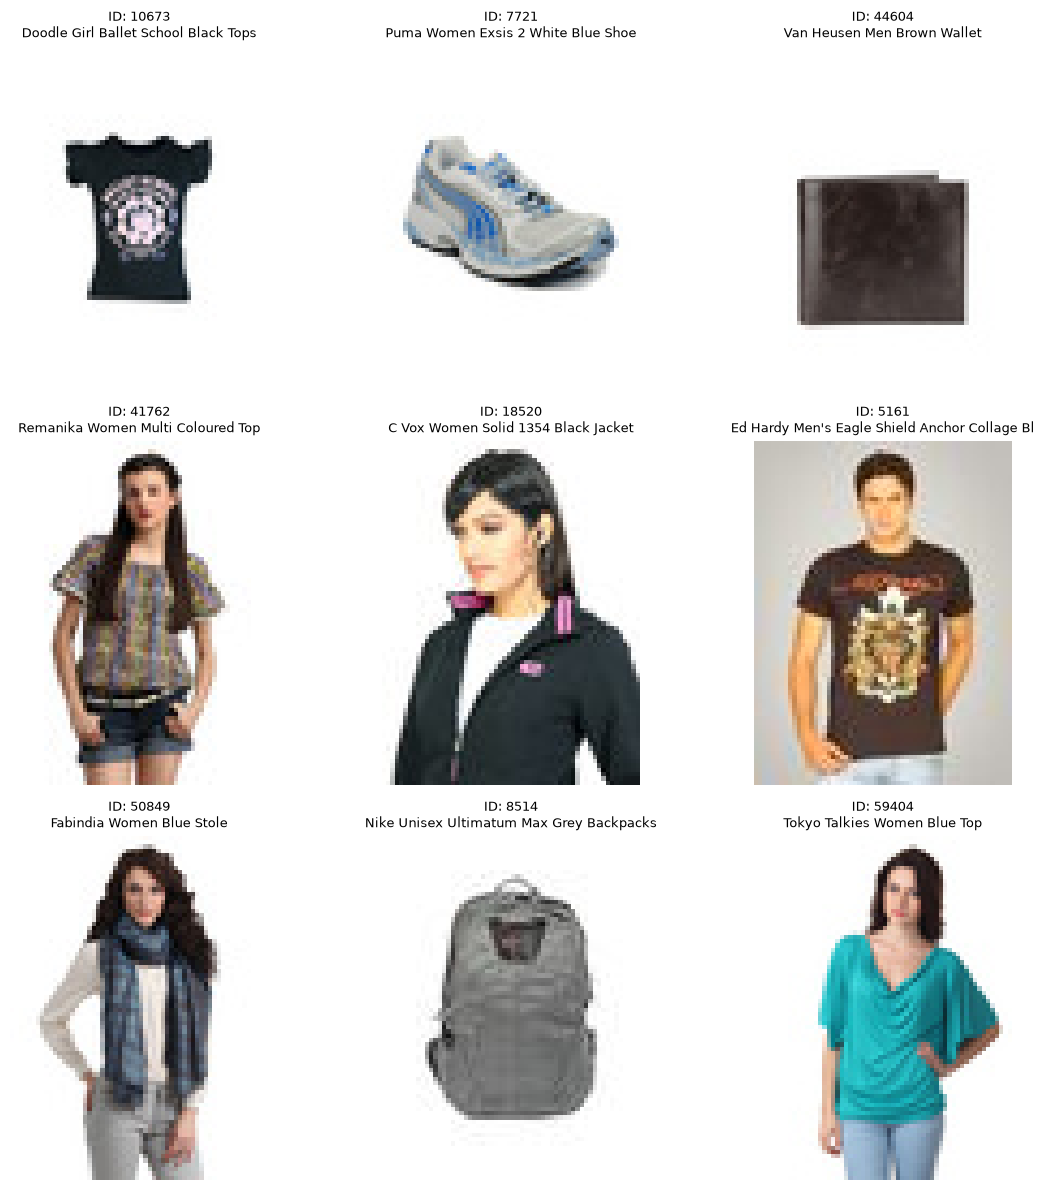

In [15]:
# Select 9 products with valid images
sample_df = df[df["image_exists"]].sample(9, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")

    ax.imshow(image)
    ax.set_title(
        f"ID: {row['id']}\n{row['productDisplayName'][:45]}",
        fontsize=9
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

### 4.2 Image Integrity Check

File existence alone does not guarantee that an image can be decoded
correctly. Therefore, every available image is opened using Pillow and
verified using `Image.verify()`.

This check identifies corrupted or unreadable image files before the
images enter the PyTorch pipeline.

In [16]:
invalid_images = []

valid_image_paths = df.loc[df["image_exists"], "image_path"]

for image_path in valid_image_paths:
    try:
        with Image.open(image_path) as img:
            img.verify()
    except Exception as e:
        invalid_images.append((image_path, str(e)))

print("Images checked:", len(valid_image_paths))
print("Invalid/corrupted images:", len(invalid_images))

Images checked: 44441
Invalid/corrupted images: 0


## 5. Dataset Cleaning and Validation

Five metadata records do not have corresponding image files. Since the
visual product search pipeline requires an image for every product,
these records cannot be used for image preprocessing or embedding
generation.

Instead of modifying the original metadata, we create a separate
`clean_df` containing only products with available images.

The original dataset is preserved, while `clean_df` becomes the working
dataset for the machine-learning pipeline.

In [17]:
clean_df = df[df["image_exists"]].copy()

print("Original records:", len(df))
print("Clean records:", len(clean_df))
print("Excluded records:", len(df) - len(clean_df))

Original records: 44446
Clean records: 44441
Excluded records: 5


In [18]:
clean_df = clean_df.reset_index(drop=True)

print(clean_df.head())
print("\nIndex range:", clean_df.index.min(), "to", clean_df.index.max())

      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

   year   usage                             productDisplayName  \
0  2011  Casual               Turtle Check Men Navy Blue Shirt   
1  2012  Casual             Peter England Men Party Blue Jeans   
2  2016  Casual                       Titan Women Silver Watch   
3  2011  Casual  Manchester United Men Solid Black Track Pants   
4  2012  Casual                          Puma Men Grey T-shirt   

                                          image_path  image_exists  
0  d:\Projects\VisualProductSearch\data\fashion-p...          Tru

### 5.1 Final Dataset Validation

After removing products without images, we verify the resulting dataset
for missing values, missing image files, and duplicate product IDs.

The cleaned dataset should contain only valid product records that can
participate in the subsequent deep-learning pipeline.

In [19]:
print("Clean dataset shape:", clean_df.shape)

print("\nMissing values:")
print(clean_df.isnull().sum())

print("\nImages missing:")
print((~clean_df["image_exists"]).sum())

print("\nDuplicate product IDs:")
print(clean_df["id"].duplicated().sum())

Clean dataset shape: (44441, 12)

Missing values:
id                    0
gender                0
masterCategory        0
subCategory           0
articleType           0
baseColour            0
season                0
year                  0
usage                 0
productDisplayName    0
image_path            0
image_exists          0
dtype: int64

Images missing:
0

Duplicate product IDs:
0


## 6. Dataset Distribution Analysis

Understanding the composition of the dataset is important before
building the visual retrieval pipeline.

We inspect several metadata attributes to understand the types of
products represented in the dataset. These statistics are descriptive
and are not used to modify the dataset.

### 6.1 Master Category Distribution

In [20]:
master_category_counts = clean_df["masterCategory"].value_counts()

print(master_category_counts)

masterCategory
Apparel           21395
Accessories       11289
Footwear           9222
Personal Care      2404
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64


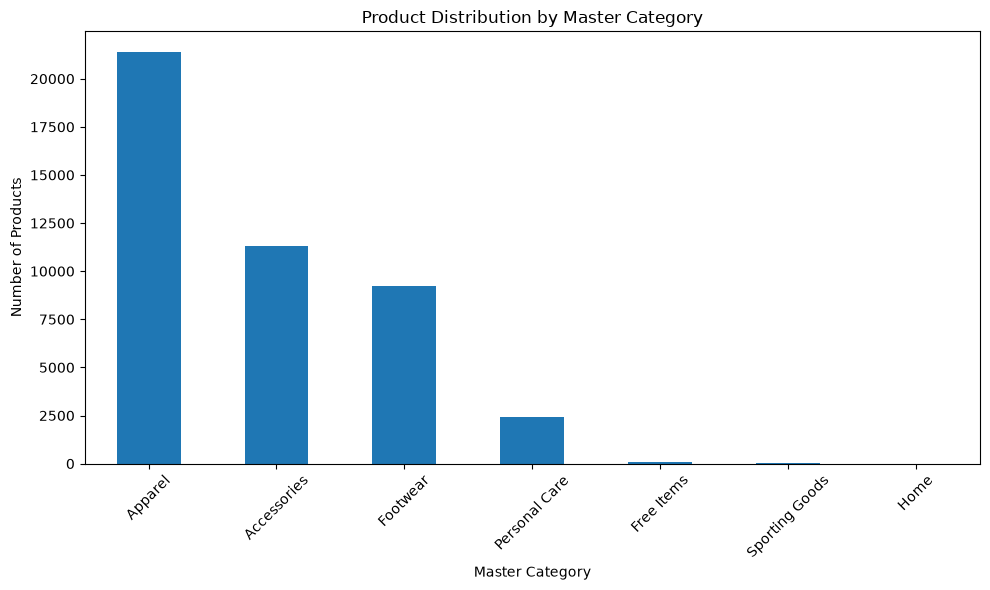

In [21]:
plt.figure(figsize=(10, 6))

master_category_counts.plot(kind="bar")

plt.title("Product Distribution by Master Category")
plt.xlabel("Master Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.2 Gender Distribution

In [22]:
gender_counts = clean_df["gender"].value_counts()

print(gender_counts)

gender
Men       22160
Women     18632
Unisex     2164
Boys        830
Girls       655
Name: count, dtype: int64


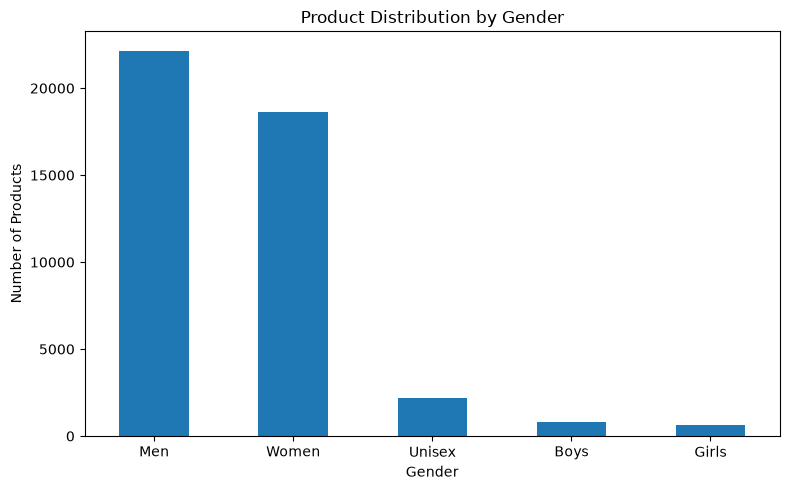

In [23]:
plt.figure(figsize=(8, 5))

gender_counts.plot(kind="bar")

plt.title("Product Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 6.3 Article Type Distribution

In [24]:
article_type_counts = clean_df["articleType"].value_counts()

print(article_type_counts.head(15))

articleType
Tshirts         7069
Shirts          3215
Casual Shoes    2846
Watches         2542
Sports Shoes    2036
Kurtas          1844
Tops            1762
Handbags        1759
Heels           1323
Sunglasses      1073
Wallets          936
Flip Flops       916
Sandals          897
Briefs           849
Belts            813
Name: count, dtype: int64


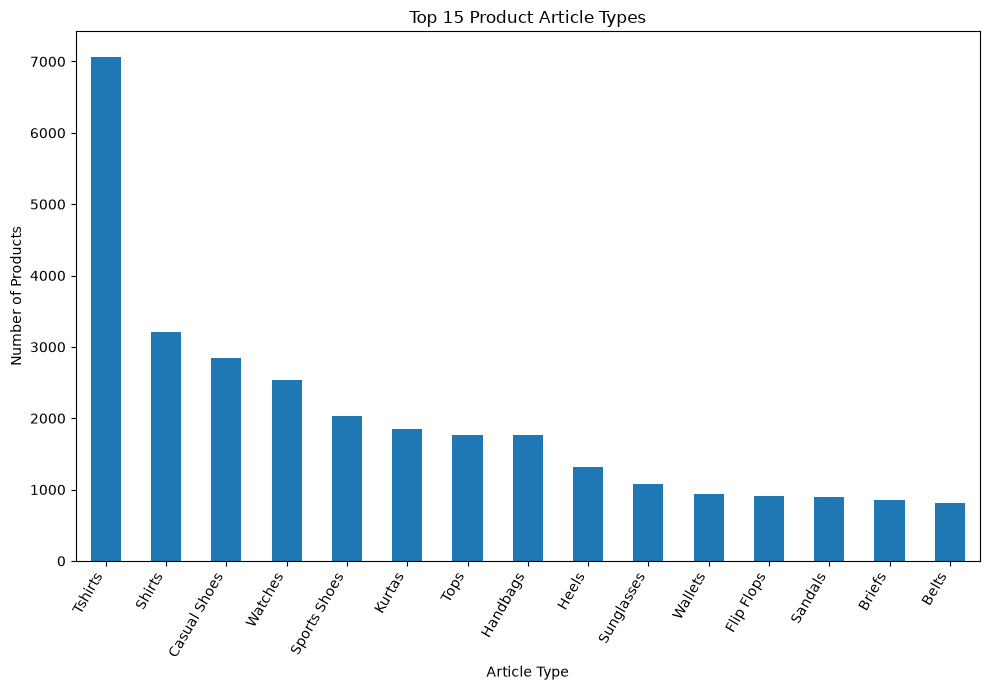

In [25]:
plt.figure(figsize=(10, 7))

article_type_counts.head(15).plot(kind="bar")

plt.title("Top 15 Product Article Types")
plt.xlabel("Article Type")
plt.ylabel("Number of Products")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

### 6.4 Base Colour Distribution

In [26]:
colour_counts = clean_df["baseColour"].value_counts()

print(colour_counts)

baseColour
Black                9731
White                5540
Blue                 4921
Brown                3494
Grey                 2741
Red                  2456
Green                2116
Pink                 1861
Navy Blue            1791
Purple               1643
Silver               1090
Yellow                779
Beige                 749
Gold                  629
Maroon                581
Orange                530
Olive                 410
Multi                 394
Cream                 389
Steel                 315
Charcoal              228
Peach                 195
Off White             182
Skin                  179
Lavender              162
Grey Melange          146
Khaki                 139
Magenta               129
Teal                  120
Tan                   114
Mustard                97
Bronze                 95
Copper                 86
Turquoise Blue         69
Rust                   66
Burgundy               45
Metallic               43
Coffee Brown           31
M

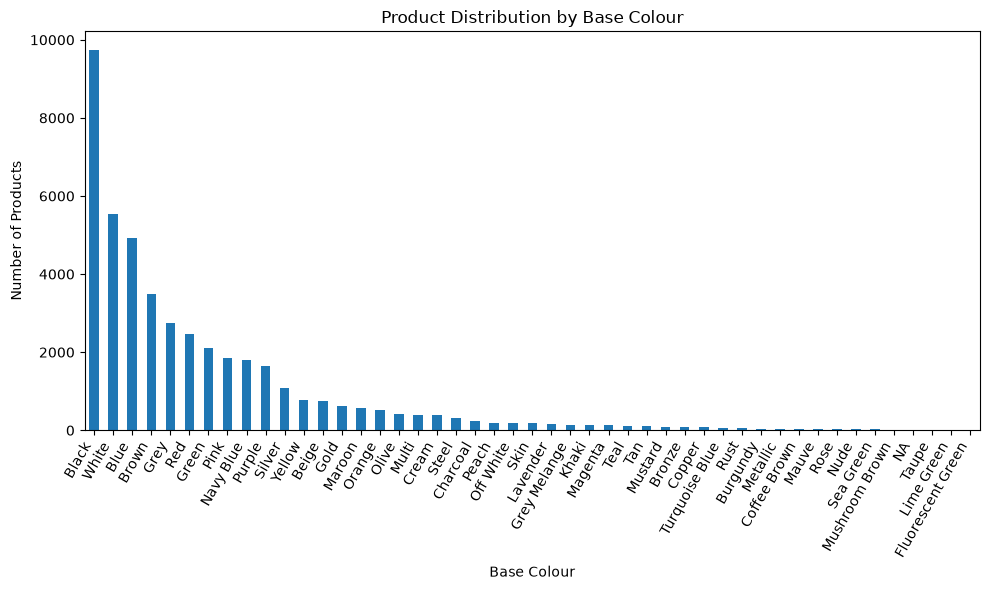

In [27]:
plt.figure(figsize=(10, 6))

colour_counts.plot(kind="bar")

plt.title("Product Distribution by Base Colour")
plt.xlabel("Base Colour")
plt.ylabel("Number of Products")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

## 7. Image Preprocessing

Deep learning models require images to be converted into a consistent
tensor representation.

The preprocessing pipeline converts each product image into an RGB
tensor with spatial dimensions of `224 × 224`. The resulting tensor
follows the PyTorch convention:

`C × H × W`

where `C = 3` represents the RGB channels.

The preprocessing pipeline consists of:

1. Resize the image to 256 pixels.
2. Center crop to `224 × 224`.
3. Convert the image to a PyTorch tensor.
4. Normalize the RGB channels using ImageNet mean and standard deviation.

The normalization parameters are required because the ResNet model used
later in the project will be initialized with pretrained ImageNet
weights.

In [28]:
image_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print(image_transform)

Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


### 7.1 Verify Preprocessing on a Sample Image

Before applying preprocessing to the complete dataset, we test the
transformation on one product image and verify its resulting tensor
shape, data type, and value range.

In [29]:
sample_row = clean_df.iloc[0]

image = Image.open(sample_row["image_path"]).convert("RGB")

print("Original image size:", image.size)

processed_image = image_transform(image)

print("Processed tensor shape:", processed_image.shape)
print("Tensor dtype:", processed_image.dtype)
print("Tensor min:", processed_image.min().item())
print("Tensor max:", processed_image.max().item())

Original image size: (60, 80)
Processed tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Tensor min: -1.7731091976165771
Tensor max: 2.640000104904175


### 7.2 Visual Verification

Normalization changes the numerical range of the tensor, so the
normalized tensor is temporarily transformed back to an approximate
display range for visualization.

This confirms that preprocessing has preserved the visual content of
the original product image.

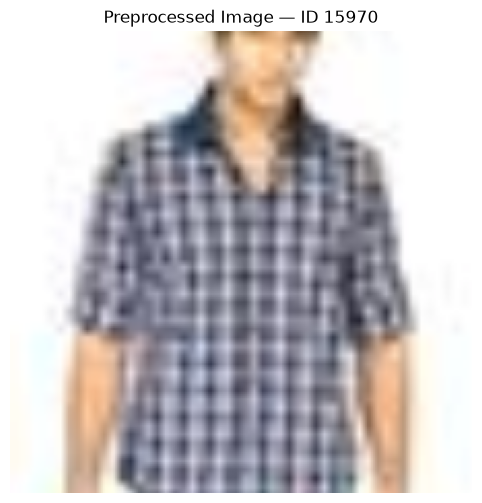

In [30]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

display_image = processed_image * std + mean
display_image = display_image.clamp(0, 1)

plt.figure(figsize=(6, 6))

plt.imshow(display_image.permute(1, 2, 0))
plt.title(f"Preprocessed Image — ID {sample_row['id']}")
plt.axis("off")

plt.show()

## 8. PyTorch Dataset

A custom PyTorch `Dataset` provides a structured interface for loading
individual product images.

For each requested product, the dataset:

1. Retrieves the corresponding metadata row.
2. Loads the image from its file path.
3. Converts the image to RGB.
4. Applies the preprocessing transformation.
5. Returns the processed image together with its product metadata.

Keeping this logic inside the Dataset allows the same preprocessing
pipeline to be reused consistently when images are later passed to the
ResNet feature extractor.

In [31]:
from torch.utils.data import Dataset


class ProductImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = row["image_path"]

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return {
            "image": image,
            "id": row["id"],
            "productDisplayName": row["productDisplayName"],
            "image_path": str(image_path)
        }

### 8.1 Create the Dataset

In [32]:
product_dataset = ProductImageDataset(
    dataframe=clean_df,
    transform=image_transform
)

print("Dataset size:", len(product_dataset))

Dataset size: 44441


### 8.2 Verify a Dataset Item

In [33]:
sample = product_dataset[0]

print("Keys:", sample.keys())
print("Image shape:", sample["image"].shape)
print("Image dtype:", sample["image"].dtype)
print("Product ID:", sample["id"])
print("Product name:", sample["productDisplayName"])

Keys: dict_keys(['image', 'id', 'productDisplayName', 'image_path'])
Image shape: torch.Size([3, 224, 224])
Image dtype: torch.float32
Product ID: 15970
Product name: Turtle Check Men Navy Blue Shirt


## 9. PyTorch DataLoader

The `Dataset` retrieves individual products, while the PyTorch
`DataLoader` groups them into batches.

A batch size of 32 is used so that images can later be processed
efficiently by the GPU during embedding generation.

Shuffling is disabled because this pipeline is used for deterministic
feature extraction rather than model training. Maintaining a stable
ordering makes it easier to map generated embeddings back to product
IDs.

In [34]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

data_loader = DataLoader(
    product_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Batch size:", BATCH_SIZE)
print("Number of batches:", len(data_loader))

Batch size: 32
Number of batches: 1389


### 9.1 Verify a Batch

We inspect one batch to confirm that the DataLoader produces the expected
tensor structure:

`B × C × H × W`

For a batch size of 32, the expected image tensor shape is:

`32 × 3 × 224 × 224`

In [35]:
batch = next(iter(data_loader))

print("Batch keys:", batch.keys())
print("Image batch shape:", batch["image"].shape)
print("Image dtype:", batch["image"].dtype)
print("First 5 product IDs:", batch["id"][:5])

print("\nFirst 5 product names:")
for name in batch["productDisplayName"][:5]:
    print("-", name)

print("\nFirst image path:")
print(batch["image_path"][0])

Batch keys: dict_keys(['image', 'id', 'productDisplayName', 'image_path'])
Image batch shape: torch.Size([32, 3, 224, 224])
Image dtype: torch.float32
First 5 product IDs: tensor([15970, 39386, 59263, 21379, 53759])

First 5 product names:
- Turtle Check Men Navy Blue Shirt
- Peter England Men Party Blue Jeans
- Titan Women Silver Watch
- Manchester United Men Solid Black Track Pants
- Puma Men Grey T-shirt

First image path:
d:\Projects\VisualProductSearch\data\fashion-product-images-small\images\15970.jpg


## 10. Save Processed Metadata

The cleaned metadata is saved separately from the original dataset.

Saving the processed metadata allows later notebooks to reuse the
validated product table without repeating the CSV repair, image matching,
and cleaning steps performed in this notebook.

The saved metadata contains only products with available images and
includes the information required to connect each product to its image.

In [36]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Processed data directory:", PROCESSED_DIR)
print("Directory exists:", PROCESSED_DIR.exists())

Processed data directory: d:\Projects\VisualProductSearch\data\processed
Directory exists: True


In [37]:
metadata_output = PROCESSED_DIR / "product_metadata.csv"

metadata_columns = [
    "id",
    "gender",
    "masterCategory",
    "subCategory",
    "articleType",
    "baseColour",
    "season",
    "year",
    "usage",
    "productDisplayName",
    "image_path"
]

clean_df[metadata_columns].to_csv(
    metadata_output,
    index=False
)

print("Saved:", metadata_output)
print("Rows saved:", len(clean_df))

Saved: d:\Projects\VisualProductSearch\data\processed\product_metadata.csv
Rows saved: 44441


### 10.1 Verify Saved Metadata

In [38]:
saved_df = pd.read_csv(metadata_output)

print("Saved dataset shape:", saved_df.shape)
print("\nColumns:")
print(saved_df.columns.tolist())

print("\nFirst 5 rows:")
display(saved_df.head())

Saved dataset shape: (44441, 11)

Columns:
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image_path']

First 5 rows:


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,d:\Projects\VisualProductSearch\data\fashion-p...
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,d:\Projects\VisualProductSearch\data\fashion-p...
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,d:\Projects\VisualProductSearch\data\fashion-p...
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,d:\Projects\VisualProductSearch\data\fashion-p...
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,d:\Projects\VisualProductSearch\data\fashion-p...


# 11. Notebook Summary

This notebook prepared and validated the product image dataset for the
visual product search pipeline.

### Dataset Validation

- Original metadata records: **44,446**
- Unique product IDs: **44,446**
- Products with available images: **44,441**
- Products excluded due to missing images: **5**
- Missing values in the cleaned dataset: **0**
- Duplicate product IDs in the cleaned dataset: **0**
- Corrupted or invalid images detected: **0**

### Preprocessing

Each product image is transformed into a normalized PyTorch tensor with
the shape:

`3 × 224 × 224`

The preprocessing pipeline consists of resizing, center cropping,
tensor conversion, and ImageNet normalization.

### PyTorch Pipeline

A custom `ProductImageDataset` and `DataLoader` were implemented and
verified.

The DataLoader successfully produces batches with the shape:

`32 × 3 × 224 × 224`

### Output

The validated product metadata is saved as:

`data/processed/product_metadata.csv`

The resulting dataset is ready to be used by the next stage of the
project, where a pretrained ResNet model will be used as a deep visual
feature extractor.